In [1]:
# Import necessary libraries
import numpy as np
import sys
from pathlib import Path
import os 
sys.path.append('../utils/')
sys.path.append('../src/')

from initial_param_SPA import initialize_parameters
from SPA import SPA
from plot_RESULT import plot_RESULT
from skimage.metrics import peak_signal_noise_ratio as psnr

In [2]:
BASE_DIR = Path(os.getcwd())

BASE_DIR = BASE_DIR.parent

In [8]:
# Hyperparameters

N_MC=1000 # Total number of MCMC iterations. By default take 1000.
N_bi=200 # Number of burn-in iterations. By default take 200.
rho=20 # User-defined standard deviation of the variable of interest x. By default take 20.
alpha=1 # User-defined hyperparameter of the prior p(u). By default take 1.
KERNEL_SIZE=39 # Size of the Kernel filter (size x size).
KERNEL_SIGMA=4 # Standard deviation of the kernel Gaussian
PATH_IMAGE= os.path.join(BASE_DIR,'utils',"lena.bmp") # path of the image x
GAMMA = 6e-3 # Regularization parameter
DELTA = 1e-1 # Regularization parameter for the Laplacian 
TARGET_SNR=20 # Target SNR in dB
SEED=1 # SEED for reproductibility

In [9]:
# Load all parameters
params = initialize_parameters(kernel_size=KERNEL_SIZE, kernel_sigma=KERNEL_SIGMA, 
                               path_image=PATH_IMAGE, gamma=GAMMA, delta = DELTA, target_SNR=TARGET_SNR, seed=SEED)

# Unpack parameters
D = params['D']
mu1 = params['mu1']
F_blur_kernel = params['F_blur_kernel']
F_Laplace = params['F_Laplace'] # smooth prior
img_noisy = params['img_noisy']
gamma = params['gamma']
N = params['N']
img_original = params['img_original']

Initial parameters loaded!


## Load workspace variables and launch SPA algorithm
Load workspace variables (defined in `../utils/initial_param_SPA.py`) and launch SPA algorithm.

In [10]:
# Run SPA algorithm
X_MC, _, _, time = SPA(D, mu1, F_blur_kernel, rho, alpha, img_noisy, gamma, F_Laplace, N, N_MC)

Sampling in progress: 100%|██████████| 999/999 [09:48<00:00,  1.70it/s]


Execution time of the Gibbs sampling: 590.08 sec


## Display PSNR and SNR
Display PSNR and SNR associated to the MMSE estimator of x.

In [14]:
# Calculate MMSE estimator (mean of samples after burn-in)
X_MMSE = np.mean(X_MC[:, :, N_bi:N_MC], axis=2)

# Calculate PSNR and SNR
PSNR = psnr(img_original.astype(np.uint8), X_MMSE.astype(np.uint8))

# Calculate SNR manually (since skimage doesn't have SNR)
signal_power = np.sum(img_original**2)
noise_power = np.sum((img_original - X_MMSE)**2)
SNR = 10 * np.log10(signal_power / noise_power)

print(f'PSNR: {PSNR:.4f} dB')
print(f'SNR: {SNR:.4f} dB')

PSNR: 25.4719 dB
SNR: 19.8725 dB


## Plot the results
Display the original image, degraded image, and reconstructed results.

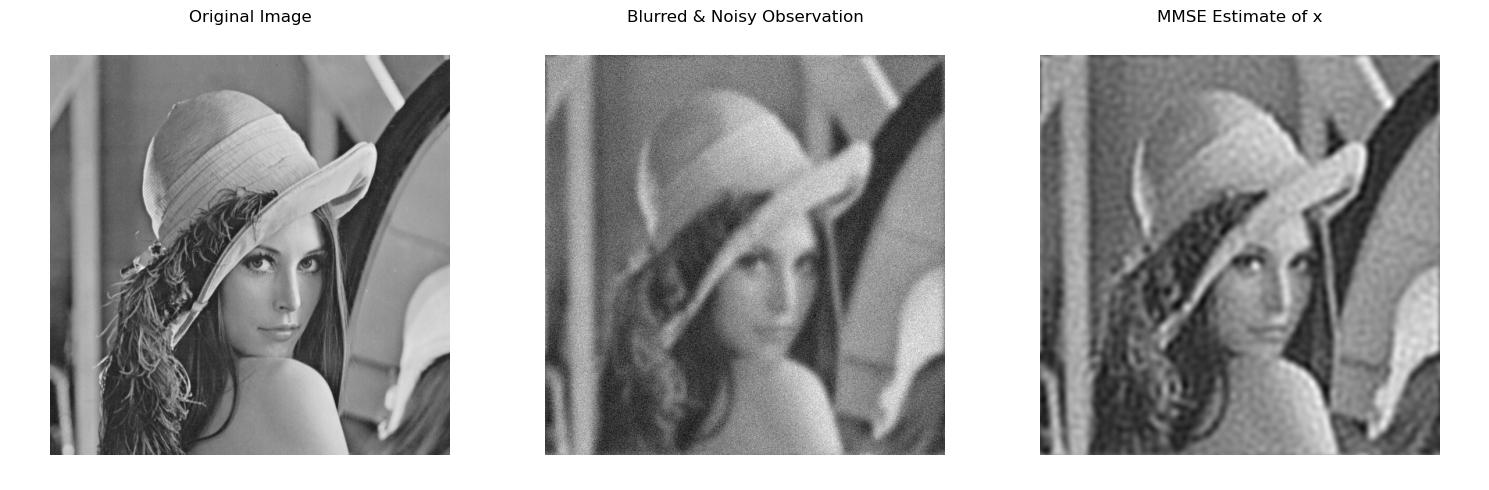

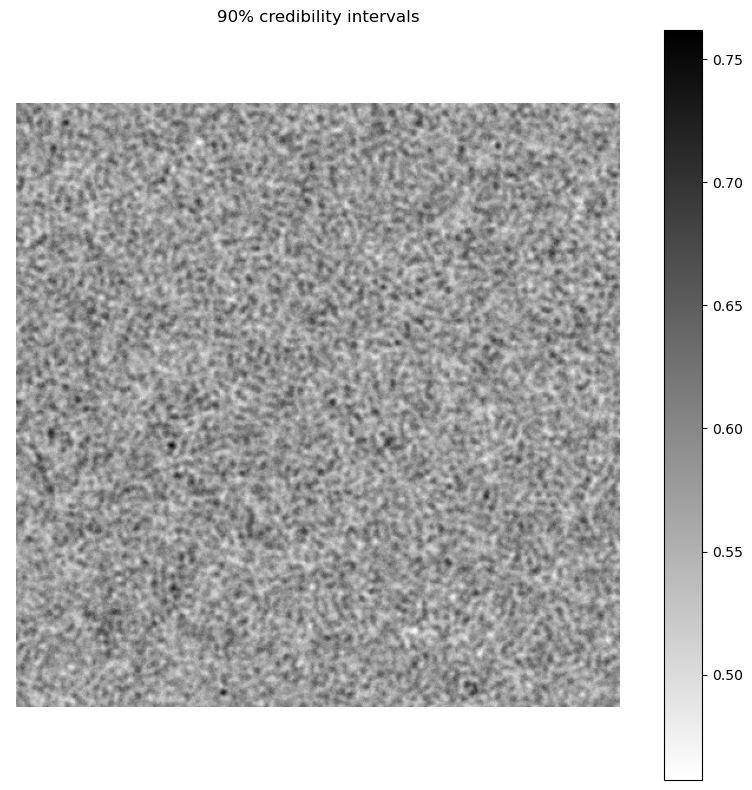

In [15]:
# Plot results
plot_RESULT(img_noisy, img_original, X_MC, N_bi, N)

## Average on 25 MC runs

In [ ]:
import numpy as np
import sys


sys.path.append('../src/')
from SPA import SPA

sys.path.append('../utils/')
from initial_param_SPA import initialize_parameters
from plot_RESULT import plot_RESULT
from skimage.metrics import peak_signal_noise_ratio as psnr


all_snr = []
all_psnr = []
all_times = []


n_runs = 25

for i in range(n_runs):
    print(f"Run {i}")
    
    # Different seed for each run to generate different img_noisy
    params = initialize_parameters(kernel_size=KERNEL_SIZE, kernel_sigma=KERNEL_SIGMA, 
                               path_image=PATH_IMAGE, gamma=GAMMA, delta = DELTA, target_SNR=TARGET_SNR, seed=i)
    
    if i == 0 : # first run we unpack once the parameters 
        # Unpack parameters
        D = params['D']
        mu1 = params['mu1']
        F_blur_kernel = params['F_blur_kernel']
        F_Laplace = params['F_Laplace'] # smooth prior
        img_noisy = params['img_noisy']
        gamma = params['gamma']
        N = params['N']
        img_original = params['img_original'] 

    img_noisy = params['img_noisy']

    X_MC, _, _ , time = SPA(D, mu1, F_blur_kernel, rho, alpha, img_noisy, gamma, F_Laplace, N, N_MC)
    
    X_MMSE = np.mean(X_MC[:, :, N_bi:N_MC], axis=2)
    
    run_psnr = psnr(img_original.astype(np.uint8), X_MMSE.astype(np.uint8))
    
    signal_power = np.sum(img_original**2)
    noise_power = np.sum((img_original - X_MMSE)**2)
    run_snr = 10 * np.log10(signal_power / noise_power)
    
    
    all_snr.append(run_snr)
    all_psnr.append(run_psnr)
    all_times.append(time)
    
    print(f"Run {i+1}/25 : SNR = {run_snr:.2f} dB, PSNR = {run_psnr:.2f} dB\n")

print("\nAVERAGE OVER 25 MONTE CARLO RUNS ")
print(f"SNR mean : {np.mean(all_snr):.2f} dB")
print(f"PSNR mean : {np.mean(all_psnr):.2f} dB")
print(f"Écart-type SNR : {np.std(all_snr):.4f}") 
print(f"Temps de calcul moyen : {np.mean(all_times):.2f} s")

Run 0
Initial parameters loaded!



Sampling in progress:  34%|███▍      | 338/999 [02:02<04:03,  2.72it/s]